In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import os

# Set data directory path
processed_dir = '../Data'

# Ensure the data directory exists
if not os.path.exists(processed_dir):
    raise FileNotFoundError(f"Directory '{processed_dir}' not found. Please run Data_Exploration_and_Split.ipynb first.")

In [2]:
def apply_pca_and_save(train_file, val_file, output_train_file, output_val_file, n_components=8):
    """
    Load train/val sets, apply standardization and PCA, then save the results.
    """
    print(f"Processing: {train_file} & {val_file}")
    
    # 1. Load data
    train_df = pd.read_csv(os.path.join(processed_dir, train_file))
    val_df = pd.read_csv(os.path.join(processed_dir, val_file))
    
    # Extract features and labels
    X_train = train_df.drop(columns=['y'])
    y_train = train_df['y']
    X_val = val_df.drop(columns=['y'])
    y_val = val_df['y']
    
    # 2. Standardization
    # PCA is sensitive to feature variance; scale to zero mean and unit variance first.
    scaler = StandardScaler()
    # Fit scaler on training set only
    X_train_scaled = scaler.fit_transform(X_train)
    # Apply to both train and val sets
    X_val_scaled = scaler.transform(X_val)
    
    # 3. Apply PCA
    pca = PCA(n_components=n_components)
    # Fit PCA on scaled training set only
    X_train_pca = pca.fit_transform(X_train_scaled)
    # Apply to val set
    X_val_pca = pca.transform(X_val_scaled)
    
    # Print cumulative explained variance to verify information retention
    explained_variance = np.sum(pca.explained_variance_ratio_) * 100
    print(f"  -> {n_components} principal components explain {explained_variance:.2f}% of the total variance.")
    
    # 4. Build new DataFrame and save
    # Create new feature column names: PC1, PC2, ..., PC8
    pca_columns = [f'PC{i+1}' for i in range(n_components)]
    
    train_pca_df = pd.DataFrame(X_train_pca, columns=pca_columns)
    train_pca_df['y'] = y_train.values  # Add label column
    
    val_pca_df = pd.DataFrame(X_val_pca, columns=pca_columns)
    val_pca_df['y'] = y_val.values      # Add label column
    
    # Save files
    train_save_path = os.path.join(processed_dir, output_train_file)
    val_save_path = os.path.join(processed_dir, output_val_file)
    
    train_pca_df.to_csv(train_save_path, index=False)
    val_pca_df.to_csv(val_save_path, index=False)
    
    print(f"  -> Saved reduced train set: {output_train_file}")
    print(f"  -> Saved reduced val set: {output_val_file}\n")
    
    return pca

In [3]:
# Target number of principal components
target_features = 8

# ---------------------------------------------------------
# Process multi-class data
# ---------------------------------------------------------
pca_multi = apply_pca_and_save(
    train_file='train_multi_raw.csv',
    val_file='val_multi_raw.csv',
    output_train_file='train_multi_reduced.csv',
    output_val_file='val_multi_reduced.csv',
    n_components=target_features
)

# ---------------------------------------------------------
# Process binary data
# ---------------------------------------------------------
pca_bin = apply_pca_and_save(
    train_file='train_bin_raw.csv',
    val_file='val_bin_raw.csv',
    output_train_file='train_bin_reduced.csv',
    output_val_file='val_bin_reduced.csv',
    n_components=target_features
)

print("All dimensionality reduction complete. Ready to train models.")

Processing: train_multi_raw.csv & val_multi_raw.csv
  -> 8 principal components explain 97.69% of the total variance.
  -> Saved reduced train set: train_multi_reduced.csv
  -> Saved reduced val set: val_multi_reduced.csv

Processing: train_bin_raw.csv & val_bin_raw.csv
  -> 8 principal components explain 97.69% of the total variance.
  -> Saved reduced train set: train_bin_reduced.csv
  -> Saved reduced val set: val_bin_reduced.csv

All dimensionality reduction complete. Ready to train models.


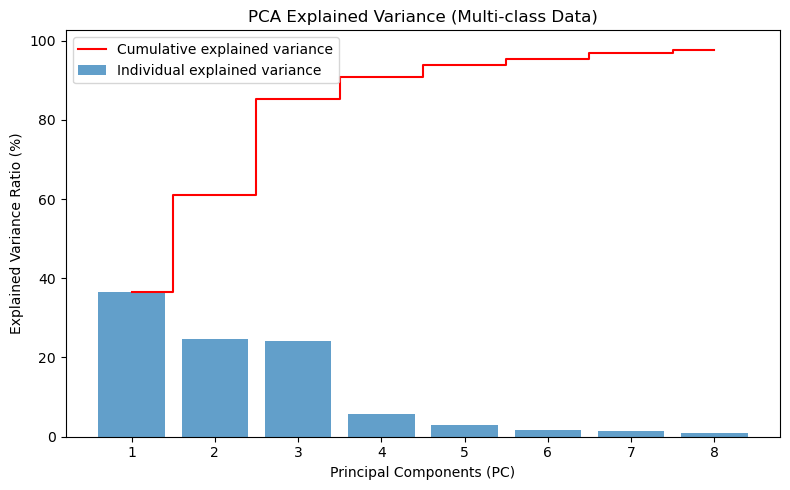

In [4]:
plt.figure(figsize=(8, 5))

# Bar chart: individual explained variance per principal component
plt.bar(range(1, target_features + 1), pca_multi.explained_variance_ratio_ * 100, alpha=0.7, align='center',
        label='Individual explained variance')

# Step plot: cumulative explained variance
plt.step(range(1, target_features + 1), np.cumsum(pca_multi.explained_variance_ratio_) * 100, where='mid',
         label='Cumulative explained variance', color='red')

plt.ylabel('Explained Variance Ratio (%)')
plt.xlabel('Principal Components (PC)')
plt.title('PCA Explained Variance (Multi-class Data)')
plt.xticks(range(1, target_features + 1))
plt.legend(loc='best')
plt.tight_layout()
plt.show()